# K-Mean Clustering

In [36]:
#import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [15]:
#import dataset
data = pd.read_csv("mall_customers.csv")
data

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [16]:
#encode gender

le = LabelEncoder()
data["gender"] = le.fit_transform(data['gender'])

del data["customer_id"]
data

,gender,age,annual_income,spending_score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
...,...,...,...,...
195,0,35,120,79
196,0,45,126,28
197,1,32,126,74
198,1,32,137,18


In [17]:
#scale thedata

se = StandardScaler()

data_scaled = se.fit_transform(data)
data_scaled[:3]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298]])

In [24]:
#baseline model

k_means = KMeans(n_clusters=3)

data["cluster"] = k_means.fit_predict(data_scaled)

In [25]:
data

,gender,age,annual_income,spending_score,cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,1
3,0,23,16,77,2
4,0,31,17,40,1
...,...,...,...,...,...
195,0,35,120,79,2
196,0,45,126,28,1
197,1,32,126,74,2
198,1,32,137,18,0


In [34]:
#GETTING OPTIMAL K
wcss = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit_predict(data_scaled)
    
    wcss.append(kmeans.inertia_)

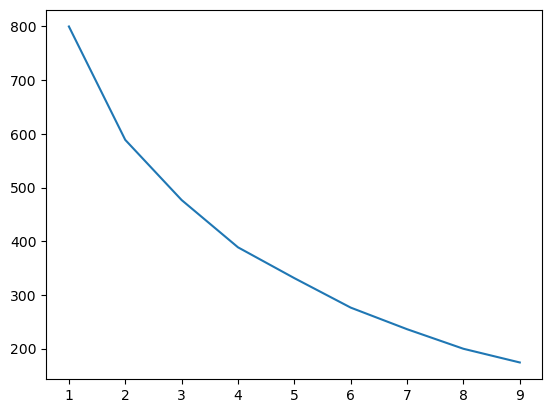

In [35]:
#plot resul
plt.plot(range(1,10), wcss, )

In [49]:
k_means = KMeans(n_clusters=4)

data["cluster"] = k_means.fit_predict(data_scaled)
data

,gender,age,annual_income,spending_score,cluster
0,1,19,15,39,0
1,1,21,15,81,0
2,0,20,16,6,1
3,0,23,16,77,1
4,0,31,17,40,1
...,...,...,...,...,...
195,0,35,120,79,2
196,0,45,126,28,3
197,1,32,126,74,2
198,1,32,137,18,3


In [50]:
#use silhoute score to get the right value of k
silt = silhouette_score(data_scaled, data["cluster"])

In [51]:
silt

0.2796656632578707